# Сегментация тетрадей

## Detectron2 baseline

В данном ноутбуке представлен baseline модели сегментации текста в школьных тетрадях с помощью фреймворка detectron2. Вы можете (и это даже лучше) использовать другие модели (например UNET, mmdet), или написать полностью свою.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 0. Установка библиотек

Установка библиотек, под которым запускается данный бейзлайн.

In [ ]:
!pip install torch==1.6.0+cu101 torchvision==0.7.0+cu101 -f https://download.pytorch.org/whl/torch_stable.html

In [ ]:
!python -m pip install detectron2 -f https://dl.fbaipublicfiles.com/detectron2/wheels/cu101/torch1.6/index.html

In [ ]:
!pip install tensorflow==2.1.0

In [ ]:
!pip install opencv-python

## 1. Загрузить необходимые библиотеки для создания и обучения модели

In [3]:
import cv2
import random
import json
import os

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore")
import ipywidgets as widgets
from ipywidgets import interact, interact_manual
import shutil

In [4]:
import tqdm

In [5]:
from matplotlib import pyplot as plt

In [6]:
import numpy as np

In [7]:
import torch, torchvision
import detectron2
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog,DatasetCatalog
from detectron2.data.datasets import register_coco_instances,load_coco_json
from detectron2.data import detection_utils as utils
from detectron2.engine import DefaultTrainer
from detectron2.engine import HookBase

# from detectron2.utils.logger import setup_logger
# setup_logger()

import logging
logger = logging.getLogger('detectron2')
logger.setLevel(logging.CRITICAL)

Прежде чем переходить к загрузке данных посмотрим, доступны ли нам GPU-мощности. 

In [8]:
print('GPU: ' + str(torch.cuda.is_available()))

GPU: True


# 2. Валидационный датасет

Для валидации наших моделей нам неплохо было создать из обучающих данных валидационный датасет. Для этого разделим наш датасет на две части - для обучения и для валидации. Для этого просто создадим два новых файлика с аннотациями, куда раздельно запишем исиходную информацию об аннотациях.

In [9]:
import json
#Подгрузим аннотации train
with open('/content/drive/MyDrive/nto/data/train_segmentation/annotations.json') as f:
    annotations = json.load(f)

In [10]:
annotations.keys()

dict_keys(['categories', 'images', 'annotations'])

In [11]:
len(annotations['images'])

932

In [12]:
len(annotations['annotations'])

161700

In [13]:
#Пустой словарь для аннотаций валидации
annotations_val = {}
#Список категорий такой же как в train
annotations_val['categories'] = annotations['categories']

#Пустой словарь для аннотаций нового train
annotations_train = {}
#Список категорий такой же как в train
annotations_train['categories'] = annotations['categories']


#Положим в валидацию каждое 12 изображение из исходного train, а остальные - в новый train
annotations_val['images'] = []
annotations_train['images'] = []
for num,img in enumerate(annotations['images']):
    if num%12==0:
        annotations_val['images'].append(img)
    else:
        annotations_train['images'].append(img)

#Положим в список аннотаций валидации только те аннотации, которые относятся к изображениям из валидации. 
#А в список аннотаций нового train - только те, которые относятся к нему
val_img_id = [i['id'] for i in annotations_val['images']]
train_img_id = [i['id'] for i in annotations_train['images']]

annotations_val['annotations'] = []
annotations_train['annotations'] = []

for annot in annotations['annotations']:
    if annot['image_id'] in val_img_id:
        annotations_val['annotations'].append(annot)
    elif annot['image_id'] in train_img_id:
        annotations_train['annotations'].append(annot)
    else:
        print('Аннотации нет ни в одном наборе')

Готово! Аннотации для валидации и новой обучающей выборки готовы, теперь просто сохраним их в формате json, и положим в папке. Назовем аннотации annotations_new.json, чтобы новая набор аннотаций для train (без множества val) не перезаписал исходные аннотации.

Запишем новые файлы с аннотациями для train и val.

In [14]:
with open('/content/drive/MyDrive/nto/data/train_segmentation/annotations_val.json', 'w') as outfile:
    json.dump(annotations_val, outfile)
    
    
with open('/content/drive/MyDrive/nto/data/train_segmentation/annotations_train.json', 'w') as outfile:
    json.dump(annotations_train, outfile)

# 3. Регистрация датасета

Зарегистрируем выборки в detectron2 для дальнейшей подачи на обучение модели.

In [15]:
for d in ['train','val']:
    DatasetCatalog.register("my_dataset_"+d, lambda d=d: load_coco_json("/content/drive/MyDrive/nto/data/train_segmentation/annotations_{}.json".format(d),
    image_root= "/content/drive/MyDrive/nto/data/train_segmentation/images",\
    dataset_name="my_dataset_"+d,extra_annotation_keys=['bbox_mode']))

После регистрации можно загружать выборки, чтобы иметь возможность посмотреть на них глазами. Первой загрузим обучающую выборку в **dataset_dicts_train**

In [16]:
dataset_dicts_train = DatasetCatalog.get("my_dataset_train")
train_metadata = MetadataCatalog.get("my_dataset_train")

И тестовую выборку в **dataset_dicts_val**

In [17]:
dataset_dicts_val = DatasetCatalog.get("my_dataset_val")
val_metadata = MetadataCatalog.get("my_dataset_val")

Посмотрим на размер получившихся выборок - эта операция в python осуществляется при помощи функции **len()**

In [18]:
print('Размер обучающей выборки (Картинки): {}'.format(len(dataset_dicts_train)))
print('Размер тестовой выборки (Картинки): {}'.format(len(dataset_dicts_val)))

Размер обучающей выборки (Картинки): 854
Размер тестовой выборки (Картинки): 78


Итак, у нас в распоряжении 588 изображения для тренировки, и 66 - для проверки качества.

**Посмотрим на размеченные фотографии из валидации**

In [19]:
import os
from IPython.display import Image
@interact
def show_images(file=range(len(dataset_dicts_val))):
    example = dataset_dicts_val[file]
    image = utils.read_image(example["file_name"], format="RGB")
    plt.figure(figsize=(5,5),dpi=200)
    visualizer = Visualizer(image[:, :, ::-1], metadata=val_metadata, scale=0.5)
    vis = visualizer.draw_dataset_dict(example)
    plt.imshow(vis.get_image()[:, :,::-1])
    plt.show()

interactive(children=(Dropdown(description='file', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, …

##   4 Обучение модели

**4.1. Определяем конфигурацию**

Прежде чем начать работать с самой моделью, нам нужно определить ее параметры и спецификацию обучения

Создаем конфигурацию и загружаем архитектуру модели с предобученными весами (на COCO - датасете, содержащем $80$ популярных категорий объектов и более $300000$ изображений) для распознавания объектов.

In [20]:
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")) 
cfg.MODEL.WEIGHTS = '/content/drive/MyDrive/nto/data/output/model_13.pth'

В целом, вы можете посмотреть и другие архитектуры в зоопарке [моделей](https://github.com/facebookresearch/detectron2/blob/master/MODEL_ZOO.md).

Теперь задаем параметры самой модели и обучения модели

In [21]:
# Загружаем названия обучающией и тестовой выборок в настройки
cfg.DATASETS.TRAIN = ("my_dataset_train",)
cfg.DATASETS.TEST = ("my_dataset_val",)

# Часто имеет смысл сделать изображения чуть меньшего размера, чтобы 
# обучение происходило быстрее. Поэтому мы можем указать размер, до которого будем изменяться наименьшая 
# и наибольшая из сторон исходного изображения.
cfg.INPUT.MIN_SIZE_TRAIN = 1000
cfg.INPUT.MAX_SIZE_TRAIN = 1000

# Также мы должны сказать модели ниже какой вероятности определения она игнорирует результат. 
# То есть, если она найдет на картинке еду, но вероятность правильного определения ниже 0.5, 
# то она не будет нам сообщать, что она что-то нашла.
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5

# Также мы должны указать порядок каналов во входном изображении. Обратите внимание, что это Blue Green Red (BGR), 
# а не привычный RGB. Это особенности работы данной модели.
cfg.INPUT.FORMAT = 'BGR' 

# Для более быстрой загрузки данных в модель, мы делаем параллельную загрузку. Мы указываем параметр 4, 
cfg.DATALOADER.NUM_WORKERS = 10

# Следующий параметр задает количество изображений в батче, на котором 
# модель делает одну итерацию обучения (изменения весов).
cfg.SOLVER.IMS_PER_BATCH = 5

# Зададим также learning_rate
cfg.SOLVER.BASE_LR = 0.01

# Укажем модели, через сколько шагов обучения модели следует уменьшить learning rate
cfg.SOLVER.STEPS = (2000,)

# Фактор, на который уменьшается learning rate задается следующим выражением
cfg.SOLVER.GAMMA = 0.1

# Зададим общее число итераций обучения.
cfg.SOLVER.MAX_ITER = 200000

# Укажем количество классов в нашей выборке
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1

# Задаем через сколько  шагов обучения сохранять веса модели в файл. Этот файл мы сможем загрузить потом 
# для тестирования нашей обученной модели на новых данных.
cfg.SOLVER.CHECKPOINT_PERIOD = 500

# И указываем название папки, куда сохранять чекпойнты модели и информацию о процессе обучения.
cfg.OUTPUT_DIR = '/content/drive/MyDrive/nto/data/output'

# Если вдруг такой папки нет, то создадим ее
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

# Если мы хотим удалить чекпойнты предыдущих моделей, то выполняем данную команду. 
#%rm output/*

**4.2. Обучаем модель**

Процесс обучения модели запускают следующие три строчки кода. Возможно будут предупреждения, на которые можно не обращать внимания, это информация об обучении.

In [ ]:
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=True)
trainer.train()

[03/04 08:52:31 d2.data.common]: Serialized dataset takes 67.84 MiB
[03/04 08:52:34 d2.engine.train_loop]: Starting training from iteration 54500
[03/04 08:53:06 d2.utils.events]:  eta: 2 days, 1:55:19  iter: 54519  total_loss: 0.4327  loss_cls: 0.02326  loss_box_reg: 0.1214  loss_mask: 0.1635  loss_rpn_cls: 0.008822  loss_rpn_loc: 0.105  time: 1.2349  data_time: 0.3791  lr: 0.001  max_mem: 8590M
[03/04 08:53:30 d2.utils.events]:  eta: 2 days, 0:32:54  iter: 54539  total_loss: 0.4116  loss_cls: 0.02198  loss_box_reg: 0.1197  loss_mask: 0.1695  loss_rpn_cls: 0.006803  loss_rpn_loc: 0.09709  time: 1.2189  data_time: 0.0438  lr: 0.001  max_mem: 8590M
[03/04 08:53:54 d2.utils.events]:  eta: 2 days, 0:11:27  iter: 54559  total_loss: 0.4028  loss_cls: 0.02137  loss_box_reg: 0.1112  loss_mask: 0.1596  loss_rpn_cls: 0.008092  loss_rpn_loc: 0.1029  time: 1.2130  data_time: 0.0555  lr: 0.001  max_mem: 8590M
[03/04 08:54:19 d2.utils.events]:  eta: 2 days, 0:32:34  iter: 54579  total_loss: 0.4339 

Используем обученную модель для проверки качества на валидации.

In [44]:
cfg.MODEL.WEIGHTS = "/content/drive/MyDrive/nto/data/output/model_0053999.pth"

cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
cfg.DATASETS.TEST = ("my_dataset_val", )
#Изменение размера исходных изображений для тестового датасета
cfg.INPUT.MIN_SIZE_TEST= 1000
cfg.INPUT.MAX_SIZE_TEST = 1000
cfg.INPUT.FORMAT = 'BGR'

#ВАЖНО увеличить это значение (стандартное равно 100). Так как на листе тетради может быть довольно много слов
cfg.TEST.DETECTIONS_PER_IMAGE = 1000

predictor = DefaultPredictor(cfg)

In [45]:
@interact
def show_images(file=range(len(dataset_dicts_val))):
    
    example = dataset_dicts_val[file]
    im = cv2.imread(example["file_name"])
    outputs = predictor(im)
    v = Visualizer(im[:, :],
                  metadata=val_metadata, 
                  scale=0.4 )
    v = v.draw_instance_predictions(outputs["instances"].to("cpu"))
    plt.figure(figsize=(5,5),dpi=200)
    plt.imshow(v.get_image()[:, :,::-1])
    plt.show()

interactive(children=(Dropdown(description='file', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, …

Можно непосредственно в коде изменить номер изображения, которое Вы хотите обработать.

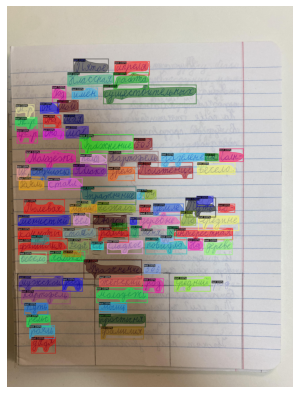

In [46]:
id_image_selected = 2
example = dataset_dicts_val[id_image_selected]
im = cv2.imread(example["file_name"])
outputs = predictor(im)
plt.figure(figsize=(7,7))
v = Visualizer(im[:, :],
              metadata=val_metadata, 
              scale=0.4 )
v = v.draw_instance_predictions(outputs["instances"].to("cpu"))
plt.imshow(v.get_image()[:, :, ::-1])
plt.axis('off')
plt.show()

В качестве предсказаний для каждого изображения из тестового набора требуется получить бинарную маску, в которой `1` означает, что данный пиксель относится к классу текста.

Давайте на примере одного изображения переведем формат выхода Detectron2 в требуемый формат для соревнования.

`outputs` - результат предсказания модели на данном изображении из предыдущего блока с кодом

In [47]:
prediction = outputs['instances'].pred_masks.cpu().numpy()

In [48]:
prediction.shape

(88, 4032, 3024)

В `prediction` находится массив бинарных матриц. Каждая матрица отвечает за отдельную задетектированную маску текста. В нашем случае модель задетектировала 80 текстовых масок. Давайте провизуализируем одну из них.

In [49]:
prediction[0]

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

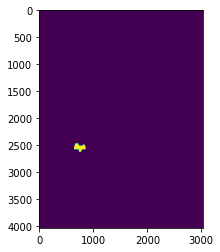

In [50]:
plt.imshow(prediction[0])

Отлично. Теперь, для того, чтобы получить бинарную маску со всем задетектированным текстом для изображения, нам нужно объединить все маски в одну. Для этого мы просто поэелементно сложим все наши матрицы. Там, где после сложения остались нули - модель не задетектировала никакого текста.

In [51]:
mask = np.add.reduce(prediction)

In [52]:
mask = mask > 0

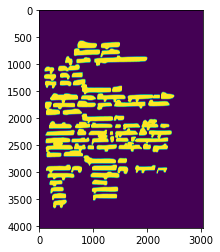

In [53]:
plt.imshow(mask)

Итак, нам нужно полуить такую маску для каждого изображения из валидационной выборки, а затем посчитать метрику F1-score.

In [54]:
#Подгрузим аннотации train
with open('/content/drive/MyDrive/nto/data/train_segmentation/annotations_val.json') as f:
    annotations_val = json.load(f)

In [55]:
val_images = annotations_val['images']

In [56]:
val_predictions = {}

In [57]:
for val_img in tqdm.tqdm_notebook(val_images):
    file_name = val_img['file_name']
    img_path = os.path.join('/content/drive/MyDrive/nto/data/train_segmentation/images/',file_name)
    im = cv2.imread(img_path)
    outputs = predictor(im)
    prediction = outputs['instances'].pred_masks.cpu().numpy()
    mask = np.add.reduce(prediction)
    mask = mask > 0
    val_predictions[file_name] = mask

  0%|          | 0/78 [00:00<?, ?it/s]

In [58]:
val_predictions

{'0_3_eng.jpg': array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]),
 '100_0.JPG': array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]),
 '101_0.jpg': array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
    

Для сохрания предсказаний и загрузки бинарных масок бы будет использовать формат `.npz`. Он позволяет хранить большие массивы в компактном виде. Вот [ссылка](https://numpy.org/doc/stable/reference/generated/numpy.savez_compressed.html) на документацию.

In [59]:
np.savez_compressed('val_pred.npz',**val_predictions)

Подгрузим бинарные маски для train и val (только что сохраненную). Так как мы в начале бейзлайна разбивали весь исходный train на новый трейн и валидацию, то информация по всем маскам из исходного train хранится в `binary.npz`. 

Получившийся после подгрузки `np.load()` - что то вроде словаря. Его ключи можно получить с помощью метода files - `loaded_val.files`. В нашем случае ключами являются ключи исходного словаря `val_predictions`, то есть названия изображений.

In [60]:
loaded_train = np.load('/content/drive/MyDrive/nto/data/train_segmentation/binary.npz')

In [61]:
loaded_val_pred = np.load('val_pred.npz')

Мы используем среднюю метрика F1-score. То есть считаем F1-score для каждого изображения, а затем усредняем результаты. 

Реализация из sklearn работает довольно долго, поэтому мы будем использовать свою.

In [62]:
def f1_loss(y_true, y_pred):
        
    
    tp = np.sum(y_true & y_pred)
    tn = np.sum(~y_true & ~y_pred)
    fp = np.sum(~y_true & y_pred)
    fn = np.sum(y_true & ~y_pred)
    iou = np.sum(y_true & y_pred)/np.sum(y_true|y_pred)
    
    epsilon = 1e-7
    
    precision = tp / (tp + fp + epsilon)
    recall = tp / (tp + fn + epsilon)
    
    f1 = 2* precision*recall / ( precision + recall + epsilon)

    return f1 , iou

In [63]:
f1_scores = []
iou = []
for key in tqdm.tqdm_notebook(loaded_val_pred.files):
    pred = loaded_val_pred[key].reshape(-1)
    true = loaded_train[key].reshape(-1)
    
    f1_img, iou_img = f1_loss(true,pred)
    f1_scores.append(f1_img)
    iou.append(iou_img)

  0%|          | 0/78 [00:00<?, ?it/s]

In [64]:
np.mean(iou), np.mean(f1_scores)

(0.7910038829844159, 0.881445448956985)

Получившаяся метрика на валидации.

# Запись submission

Как уже говорилось ранее, правильные и предсказанные маски мы будем хранить в компактном формате `npz`. 

Возьмем нашу обученную модель и запишем предсказания в файл `prediction.npz`

In [ ]:
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.structures import Boxes, BoxMode 


In [ ]:
def run(test_images_path,predictions_output_path):
    threshold = 0.5
    model_path = "/content/drive/MyDrive/nto/data/model_final.pth"
    
    
    cfg = get_cfg()
    cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")) 
    cfg.MODEL.WEIGHTS = model_path
    cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = threshold   # set the testing threshold for this model
    cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1
    cfg.INPUT.MIN_SIZE_TEST= 600
    cfg.INPUT.MAX_SIZE_TEST = 600
    cfg.INPUT.FORMAT = 'BGR'
    cfg.TEST.DETECTIONS_PER_IMAGE = 1000
    
    
    
    predictor = DefaultPredictor(cfg)
    results = {}
    
    
    for img in os.listdir(test_images_path):
        img_path = os.path.join(test_images_path,img)
        im = cv2.imread(img_path)
        outputs = predictor(im)
        prediction = outputs['instances'].pred_masks.cpu().numpy()
        mask = np.add.reduce(prediction)
        mask = mask > 0
        
        results[img] = mask  
    np.savez_compressed(predictions_output_path,**results)


В функцию передаем два аргумента:
* путь к папке с изображениями, на которых хотим сделать предсказания. сейчас это путь к валдиационными изображениям. Папку test мы положим во время запуска контейнера.
* путь к создаваемому файлу с предсказаниями. по время локального дебага можно использовать любое имя

Этот же код вынесен в отдельные скрипты для удобства, они должны запускаться во время запуска контейнера.

# Оценка качества.

Оценка качества на нашей стороне просходит по следующему скрипту - `evaluate.py`. Он принимает на вход путь к двум файлам формата `npz`. 
* `ref_path` - путь к файлу с правильными ответами 
* `pred_path` - путь к файлу с предсказаниями

Для начала сгенерируем файл формата `npz` для валидации.

In [ ]:
val_true = {}
for i in loaded_train.files:
    if i in val_predictions.keys():
        val_true[i] = loaded_train[i]

In [ ]:
np.savez_compressed('val_true.npz',**val_true)

In [ ]:
!python evaluate.py --ref_path val_true.npz --pred_path val_pred.npz

python3: can't open file 'evaluate.py': [Errno 2] No such file or directory
python3: can't open file 'evaluate.py': [Errno 2] No such file or directory
